In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import libraries
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import os, re, time, math, tqdm, itertools
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.offline as pyo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef
import keras
from keras.models import Sequential
from keras.layers import Conv2D, Conv1D, MaxPooling2D, MaxPooling1D, Flatten, BatchNormalization, Dense, Dropout
from keras.callbacks import CSVLogger, ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from hyperopt import fmin, hp, tpe, Trials, STATUS_OK
from hyperopt.plotting import main_plot_history, main_plot_vars
import uuid
import gc
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
import datetime as dt

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Dataset/Dataset to Expreminte1.csv')

In [ ]:
data.drop(['Timestamp'], axis=1)

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,3,112641719,3,0,0,0,0,0,0.000000,...,0,0,0.0,0,0,56320859.5,139.300036,56320958.0,56320761.0,Benign
1,0,3,112641466,3,0,0,0,0,0,0.000000,...,0,0,0.0,0,0,56320733.0,114.551299,56320814.0,56320652.0,Benign
2,0,3,112638623,3,0,0,0,0,0,0.000000,...,0,0,0.0,0,0,56319311.5,301.934596,56319525.0,56319098.0,Benign
3,22,15,6453966,15,10,1239,2273,744,0,82.600000,...,32,0,0.0,0,0,0.0,0.000000,0.0,0.0,Benign
4,22,14,8804066,14,11,1143,2209,744,0,81.642857,...,32,0,0.0,0,0,0.0,0.000000,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112495,80,2,6306,2,0,0,0,0,0,0.000000,...,20,0,0.0,0,0,0.0,0.000000,0.0,0.0,SQL Injection
112496,80,4,5010270,4,4,660,395,660,0,165.000000,...,20,0,0.0,0,0,0.0,0.000000,0.0,0.0,SQL Injection
112497,80,2,26,2,0,0,0,0,0,0.000000,...,20,0,0.0,0,0,0.0,0.000000,0.0,0.0,SQL Injection
112498,80,5,5005197,5,3,694,1903,694,0,138.800000,...,20,0,0.0,0,0,0.0,0.000000,0.0,0.0,SQL Injection


In [ ]:
data["Label"].value_counts(normalize=True)

,proportion
Label,
Benign,0.066667
FTP-BruteForce,0.066667
SSH-Bruteforce,0.066667
DoS attacks-GoldenEye,0.066667
DoS attacks-Slowloris,0.066667
DoS attacks-Hulk,0.066667
DoS attacks-SlowHTTPTest,0.066667
DDOS attack-HOIC,0.066667
Infilteration,0.066667


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112500 entries, 0 to 112499
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           112500 non-null  int64  
 1   Protocol           112500 non-null  int64  
 2   Timestamp          112500 non-null  float64
 3   Flow Duration      112500 non-null  int64  
 4   Tot Fwd Pkts       112500 non-null  int64  
 5   Tot Bwd Pkts       112500 non-null  int64  
 6   TotLen Fwd Pkts    112500 non-null  int64  
 7   TotLen Bwd Pkts    112500 non-null  int64  
 8   Fwd Pkt Len Max    112500 non-null  int64  
 9   Fwd Pkt Len Min    112500 non-null  int64  
 10  Fwd Pkt Len Mean   112500 non-null  float64
 11  Fwd Pkt Len Std    112500 non-null  float64
 12  Bwd Pkt Len Max    112500 non-null  int64  
 13  Bwd Pkt Len Min    112500 non-null  int64  
 14  Bwd Pkt Len Mean   112415 non-null  float64
 15  Bwd Pkt Len Std    112500 non-null  float64
 16  Fl

In [ ]:
# Select the features for correlation analysis
features = ['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
            'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
            'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
            'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
            'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
            'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
            'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
            'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
            'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
            'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
            'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
            'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
            'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
            'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
            'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg',
            'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg',
            'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Subflow Fwd Pkts',
            'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts',
            'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts',
            'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max',
            'Active Min', 'Idle Mean', 'Idle Std','Idle Max','Idle Min','Label']

# Create the subset DataFrame
subset = data[features]

# Exclude non-numeric columns from the subset
numeric_subset = subset.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_subset.corr()

# Display the correlation matrix
print(correlation_matrix)

               Dst Port  Protocol  Timestamp  Flow Duration  Tot Fwd Pkts  \
Dst Port       1.000000 -0.058171  -0.104753      -0.109137     -0.058171   
Protocol      -0.058171  1.000000  -0.118966       0.650234      1.000000   
Timestamp     -0.104753 -0.118966   1.000000       0.216837     -0.118966   
Flow Duration -0.109137  0.650234   0.216837       1.000000      0.650234   
Tot Fwd Pkts  -0.058171  1.000000  -0.118966       0.650234      1.000000   
...                 ...       ...        ...            ...           ...   
Active Min    -0.027627 -0.037234   0.125585       0.266449     -0.037234   
Idle Mean     -0.052710 -0.063577  -0.018660       0.487941     -0.063577   
Idle Std      -0.039276 -0.050697   0.201484       0.402362     -0.050697   
Idle Max      -0.058178 -0.070954   0.033838       0.548950     -0.070954   
Idle Min      -0.046782 -0.055758  -0.058289       0.425651     -0.055758   

               Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  \
Dst Port  

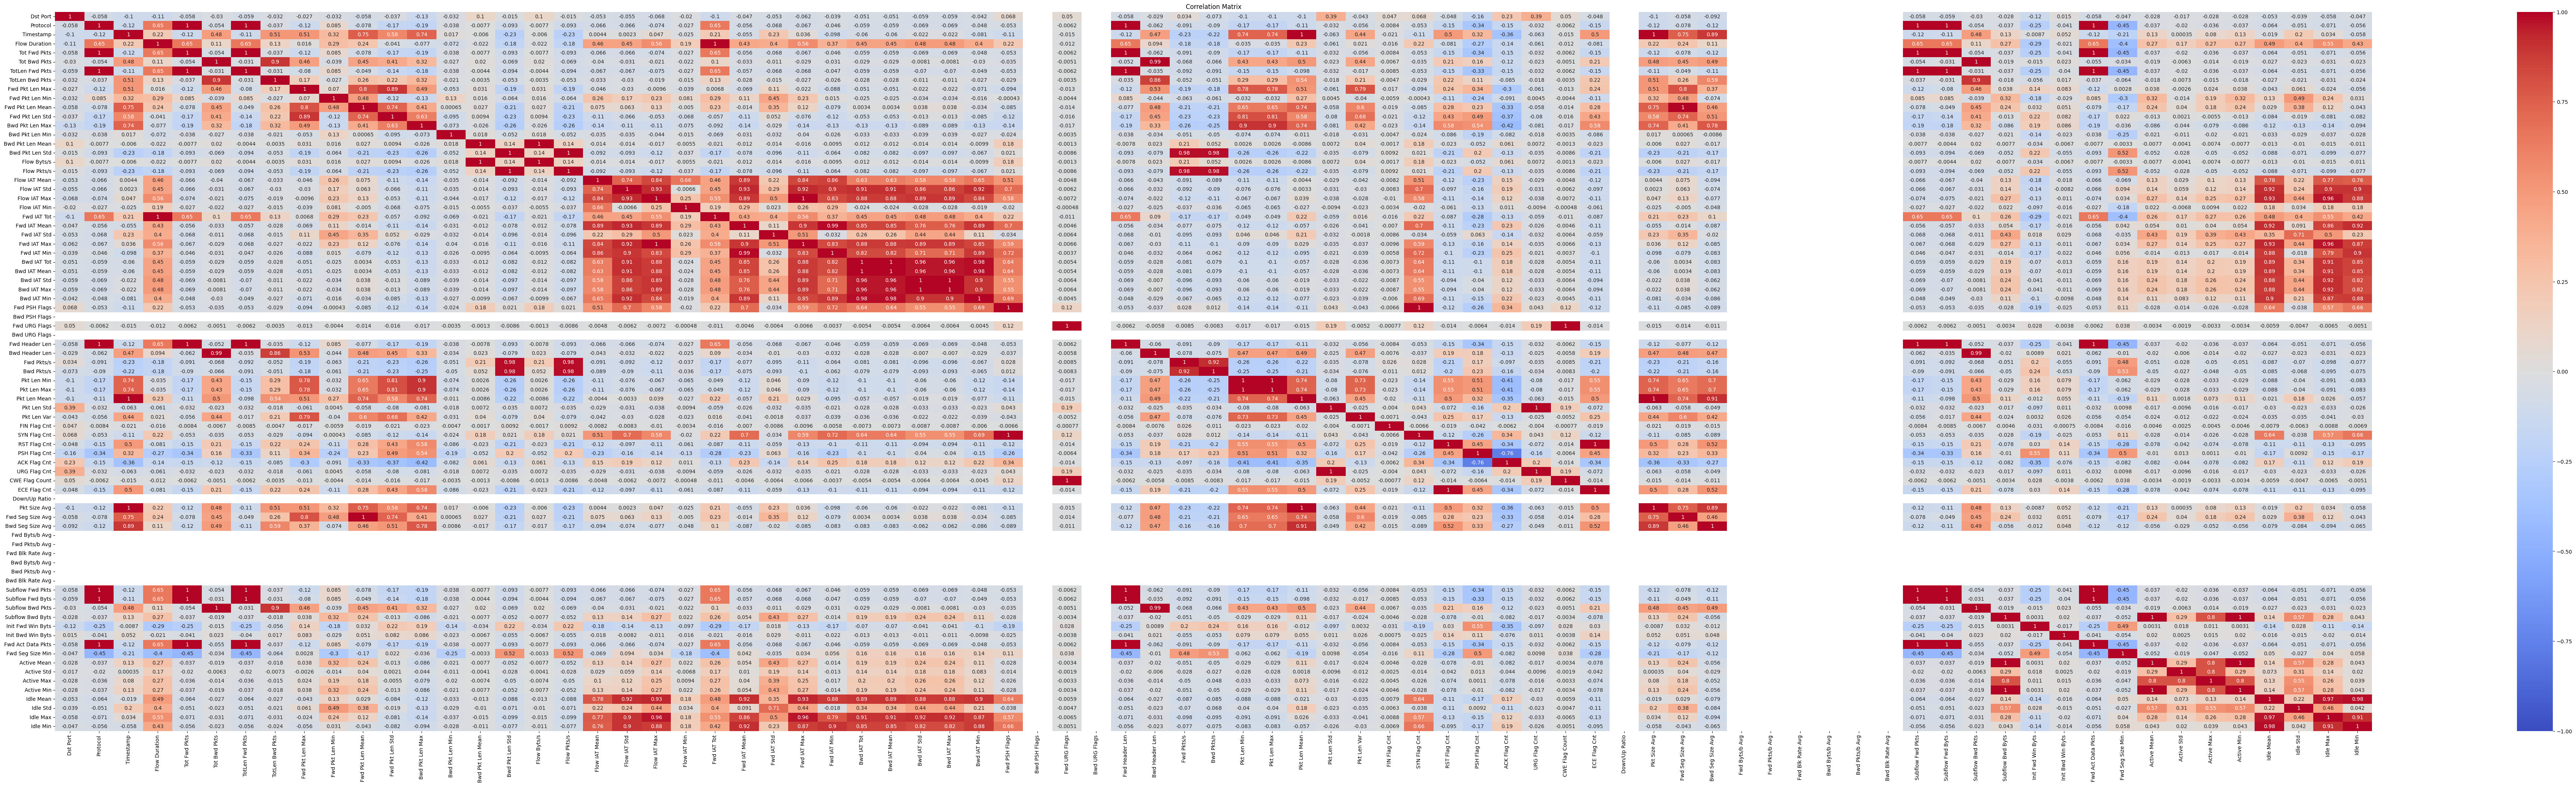

In [ ]:
# Select the features for correlation analysis
features = ['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
            'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
            'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
            'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
            'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
            'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
            'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
            'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
            'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
            'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
            'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
            'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
            'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
            'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
            'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg',
            'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg',
            'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Subflow Fwd Pkts',
            'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts',
            'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts',
            'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max',
            'Active Min', 'Idle Mean', 'Idle Std','Idle Max','Idle Min','Label' ]

# Calculate the correlation matrix
correlation_matrix = numeric_subset.corr()

# Plot the correlation matrix
plt.figure(figsize=(100, 25))
sns.heatmap(correlation_matrix, vmin=-1, vmax=1, cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# drop na values and reset index
data_clean = data.dropna().reset_index()

# label encoding
labelencoder = LabelEncoder()
data_clean['Label'] = labelencoder.fit_transform(data_clean['Label'])

data_np = data_clean.to_numpy(dtype="float32")
# drop inf values
data_np = data_np[~np.isinf(data_np).any(axis=1)]

X = data_np[:, 0:78]

enc = OneHotEncoder()

Y = enc.fit_transform(data_np[:, 80:]).toarray()

# Scale data to have mean 0 and variance 1
# which is important for convergence of the neural network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Outlier detection using Local Outlier Factor (LOF)
lof = LocalOutlierFactor(contamination=0.05)  # contamination: expected proportion of outliers
outliers = lof.fit_predict(X_scaled) == -1

# Remove outliers from the data
X_cleaned = X_scaled[~outliers]
Y_cleaned = Y[~outliers]

# Split the data set into training and testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X_cleaned, Y_cleaned, test_size=0.20, random_state=2, shuffle=True)

_features = X.shape[1]
n_classes = Y.shape[1]


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(85400, 78)
(21350, 78)
(85400, 15)
(21350, 15)


In [ ]:
def model():
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=5, activation='relu', padding='same', input_shape=(78, 1)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=3, strides=2, padding='same'))

    model.add(Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=3, strides=2, padding='same'))

    model.add(Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=3, strides=2, padding='same'))

    model.add(Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(MaxPooling1D(pool_size=3, strides=2, padding='same'))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(15, activation='softmax'))

    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.0001)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model


In [ ]:
model = model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 78, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 78, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 78, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 39, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 39, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 10, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,519 (1.55 MB)

 Trainable params: 404,495 (1.54 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
logger = CSVLogger('logs.csv', append=True)
his = model.fit(X_train, Y_train, epochs=10, batch_size=64,
          validation_data=(X_test, Y_test), callbacks=[logger])

Epoch 1/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 137s 100ms/step - accuracy: 0.7315 - loss: 0.8376 - val_accuracy: 0.9593 - val_loss: 0.1024
Epoch 2/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 131s 98ms/step - accuracy: 0.9574 - loss: 0.1073 - val_accuracy: 0.9762 - val_loss: 0.0574
Epoch 3/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 133s 99ms/step - accuracy: 0.9715 - loss: 0.0736 - val_accuracy: 0.9926 - val_loss: 0.0302
Epoch 4/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 129s 97ms/step - accuracy: 0.9782 - loss: 0.0572 - val_accuracy: 0.9909 - val_loss: 0.0287
Epoch 5/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 143s 98ms/step - accuracy: 0.9806 - loss: 0.0493 - val_accuracy: 0.9826 - val_loss: 0.0436
Epoch 6/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 132s 99ms/step - accuracy: 0.9834 - loss: 0.0430 - val_accuracy: 0.9901 - val_loss: 0.0266
Epoch 7/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 138s 96ms/step - accuracy: 0.9862 - loss: 0.0386 - val_accuracy: 0.9925 - val_loss: 0.0203
Epoch 8/10
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 129s 97ms/step - accuracy:

In [ ]:
scores = model.evaluate(X_test, Y_test)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))

668/668 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9923 - loss: 0.0197
compile_metrics: 99.18%


In [ ]:
def confusion_matrix_func(y_test, y_test_pred):

    '''
    This function computes the confusion matrix using Predicted and Actual values and plots a confusion matrix heatmap
    '''
    C = confusion_matrix(y_test, y_test_pred)
    cm_df = pd.DataFrame(C)
    labels = ['Benign','Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP',
              'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SQL Injection', 'SSH-Bruteforce']
    plt.figure(figsize=(20,15))
    sns.set(font_scale=1.4)
    sns.heatmap(cm_df, annot=True, annot_kws={"size":12}, fmt='g', xticklabels=labels, yticklabels=labels)
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')

    plt.show()

# calculate roc curve
from sklearn.metrics import *
#fpr_RF, tpr_RF, thresholds_RF = roc_curve(y_test, pred)
from sklearn import preprocessing
def multiclass_roc_auc_score(y_test, pred, average="macro"):
    lb = preprocessing.LabelBinarizer()
    lb.fit(y_test)
    y_test = lb.transform(y_test)
    pred = lb.transform(pred)
    return roc_auc_score(y_test, pred, average=average)

In [ ]:
print('Train data')
print(X_train.shape)
print(Y_train.shape)
print('='*20)
print('Test data')
print(X_test.shape)
print(Y_test.shape)
print('='*20)

# Measure accuracy
print('Predicting on the test data:')
start = dt.datetime.now()
escore = model.evaluate(X_test, Y_test, batch_size=128)
pred = model.predict(X_test)
pred = np.argmax(pred, axis=1)
y_eval = np.argmax(Y_test, axis=1)

# Compute various evaluation metrics
vscore = accuracy_score(y_eval, pred)
rscore = recall_score(y_eval, pred, average='weighted')
ascore = precision_score(y_eval, pred, average='weighted')
f1score = f1_score(y_eval, pred, average='weighted')  # F1 = 2 * (precision * recall) / (precision + recall)
accuracy = multiclass_roc_auc_score(y_eval, pred)

# Adding MCC
mcc = matthews_corrcoef(y_eval, pred)

print('Completed')
print('Time taken:', dt.datetime.now() - start)
print('='*50)
print("Validation score: {}".format(vscore))
print('='*50)
print("Evaluation score: {}".format(escore))
print('='*50)
print("Recall score: {}".format(rscore))
print('='*50)
print("Precision score: {}".format(ascore))
print('='*50)
print("F1 score: {}".format(f1score))
print('='*50)
print("MCC score: {}".format(mcc))  # Printing MCC score
print('='*50)


Train data
(85400, 78)
(85400, 15)
Test data
(21350, 78)
(21350, 15)
Predicting on the test data:
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9922 - loss: 0.0197
668/668 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
Completed
Time taken: 0:00:12.475163
Validation score: 0.9918032786885246
Evaluation score: [0.020397691056132317, 0.9918032884597778]
Recall score: 0.9918032786885246
Precision score: 0.9920404662661308
F1 score: 0.9917919853636326
MCC score: 0.9912362786984528


In [ ]:
history = his.history
history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

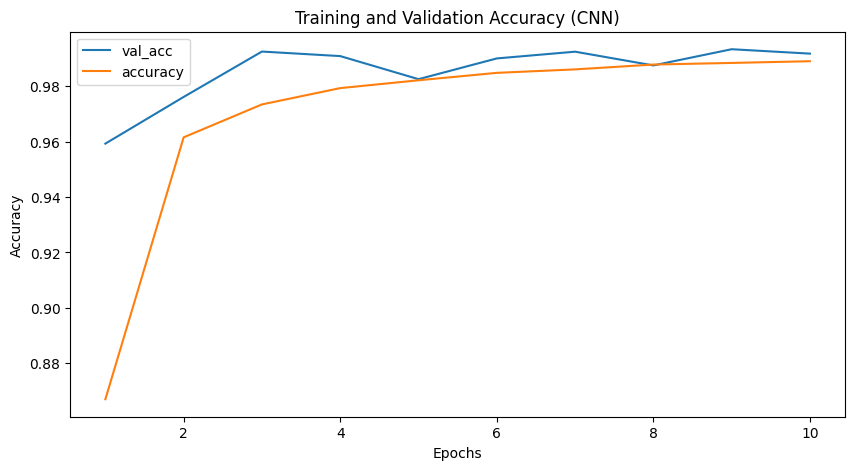

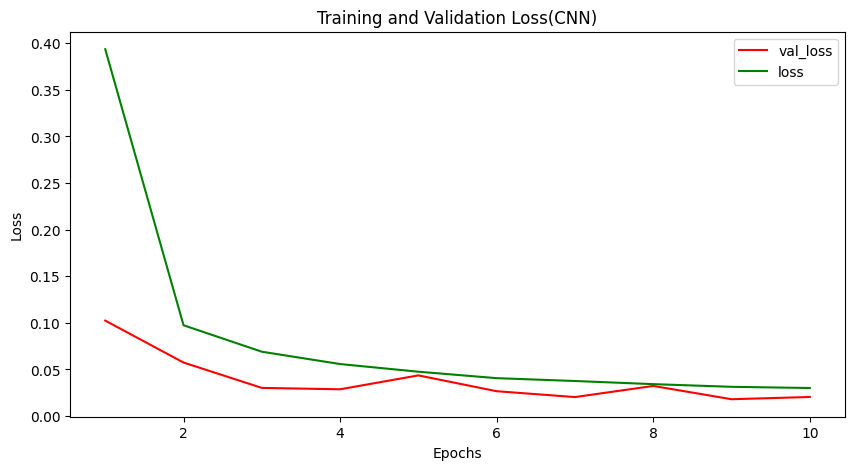

In [ ]:
epochs = range(1, len(history['loss']) + 1)
acc = history['accuracy']
loss = history['loss']
val_acc = history['val_accuracy']
val_loss = history['val_loss']

# visualize training and val accuracy
plt.figure(figsize=(10, 5))
plt.title('Training and Validation Accuracy (CNN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(epochs, val_acc, label='val_acc')
plt.plot(epochs, acc, label='accuracy')
plt.legend()

# visualize train and val loss
plt.figure(figsize=(10, 5))
plt.title('Training and Validation Loss(CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(epochs, val_loss, label='val_loss', color='r')
plt.plot(epochs, loss, label='loss', color='g')
plt.legend()

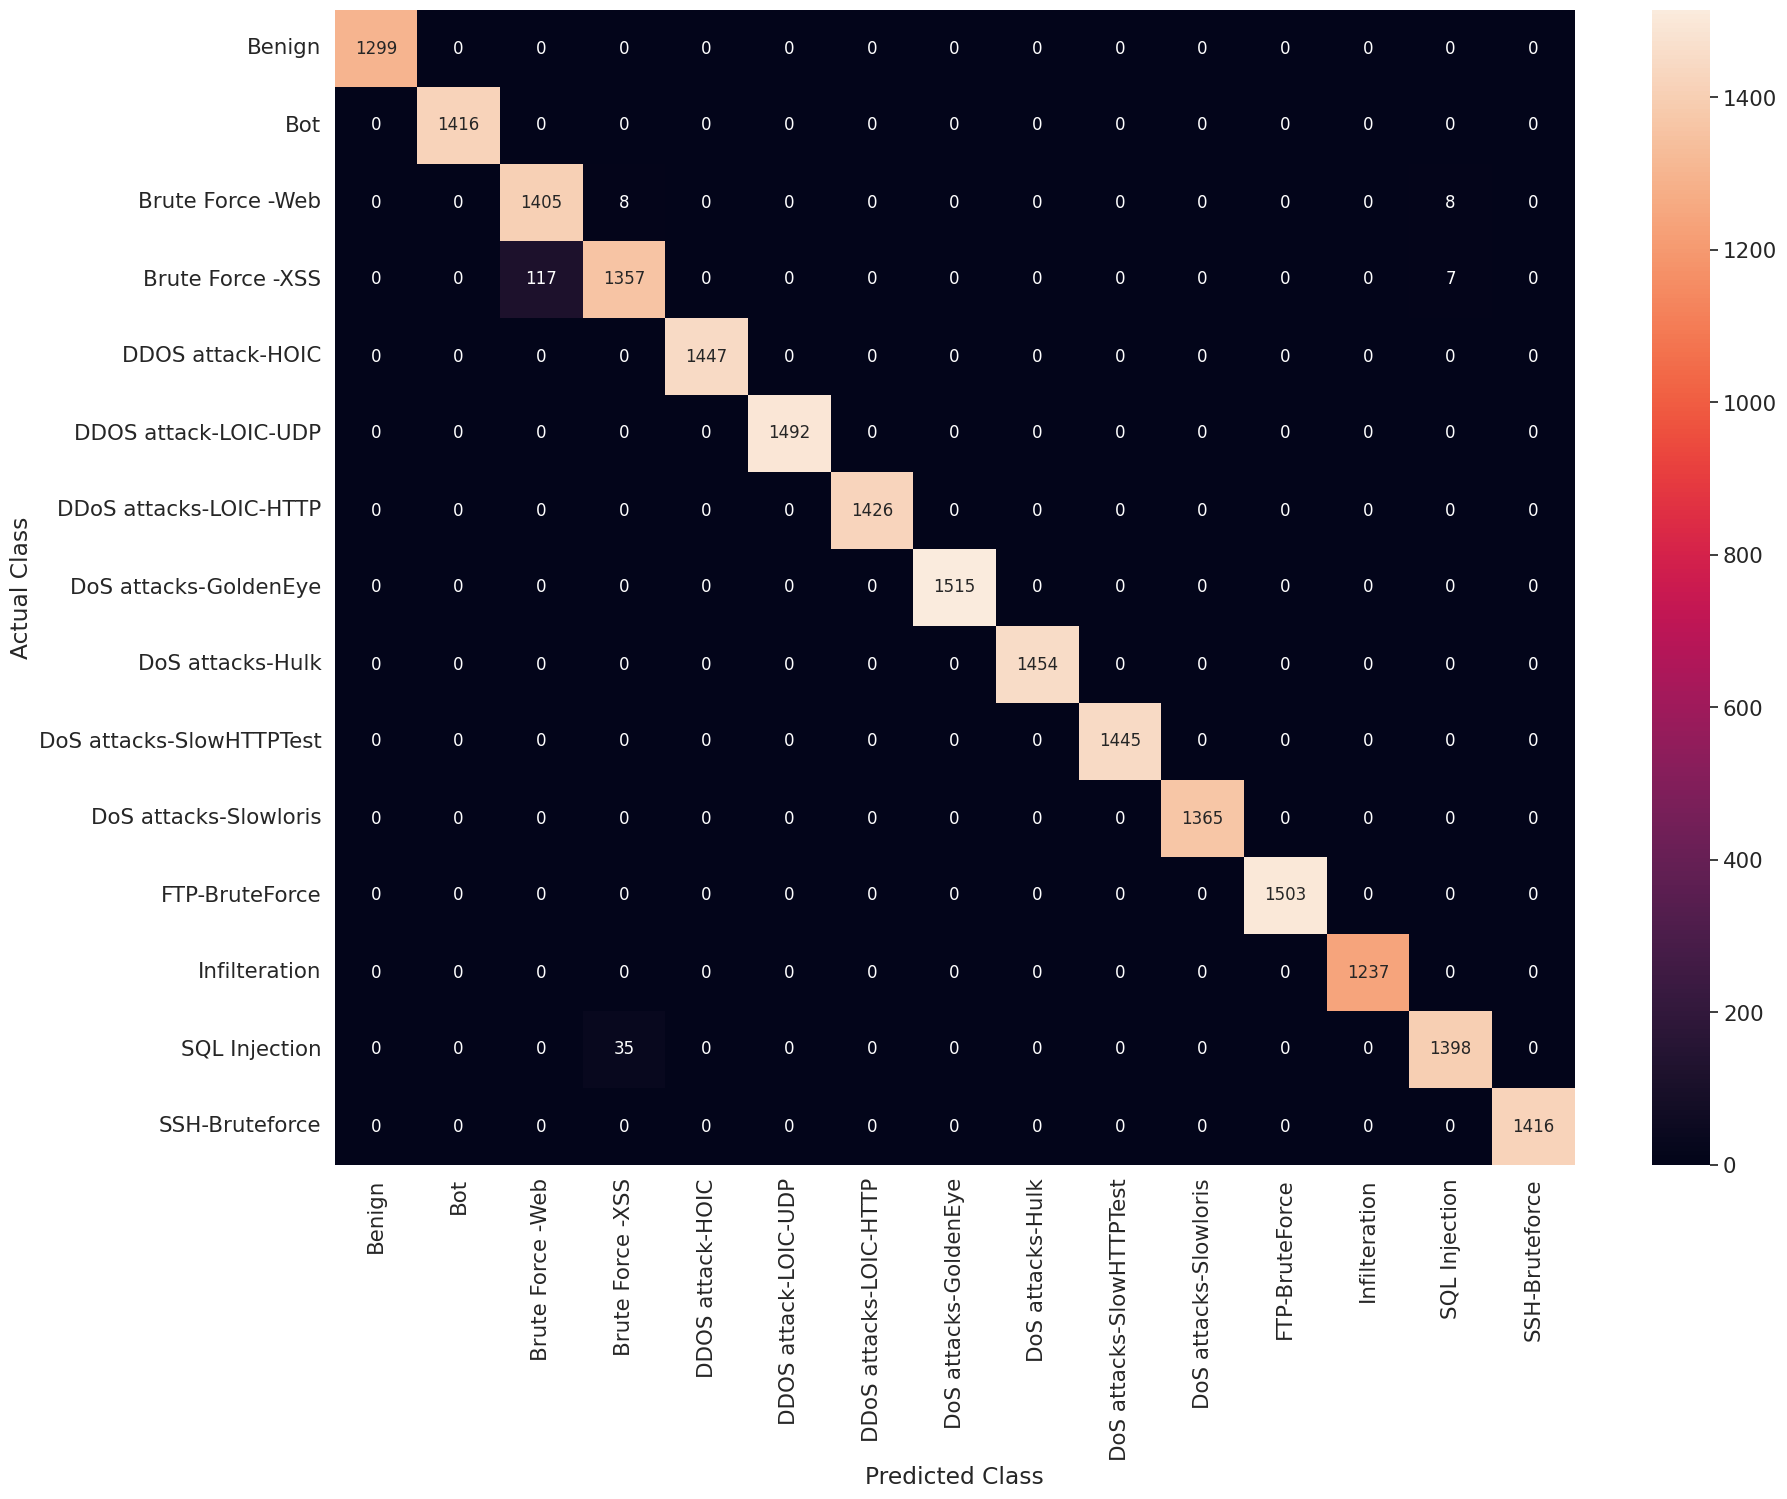

In [ ]:
confusion_matrix_func(y_eval, pred)